## Application of k-Anonymity, l-Diversity, m-Invariance, and t-Closeness

In [ ]:
import pandas as pd

# Load the data
train_df = pd.read_csv('pproject_train.csv')
test_df = pd.read_csv('pproject_test.csv')


print("Original Train Data:")
print(train_df.head())

print("\nOriginal Test Data:")
print(test_df.head())

Original Train Data:
      0     1      2    3    4    5    6 blood_pressure
0  55.0   0.0  199.0  0.0  1.0  1.0  0.0            NaN
1  51.0  15.0  267.0  0.0  1.0  0.0  1.0         121/72
2  44.0   0.0  243.0  0.0  1.0  1.0  0.0       127.5/76
3  45.0  25.0  288.0  0.0  1.0  0.0  1.0       122.5/80
4  40.0  19.0  233.0  0.0  1.0  0.0  1.0         119/80

Original Test Data:
    age  cigs_per_day   chol  male  female  smoker_yes  smoker_no  \
0  40.0           0.0  193.0   0.0     1.0         1.0        0.0   
1  59.0           0.0  236.0   0.0     1.0         1.0        0.0   
2  64.0           0.0  232.0   1.0     0.0         1.0        0.0   
3  48.0          20.0  202.0   1.0     0.0         0.0        1.0   
4  51.0           6.0  190.0   1.0     0.0         0.0        1.0   

  blood_pressure  
0         110/72  
1         130/80  
2         130/80  
3         130/80  
4         130/80  


### Handle NaN values

In [ ]:
# Option 1: Remove rows with NaN values in critical columns
train_df = train_df.dropna(subset=['blood_pressure'])

# Option 2: Fill NaN values for other columns
train_df = train_df.fillna(train_df.mean(numeric_only=True))  # Fill NaN with mean for numerical columns
train_df = train_df.fillna('Unknown')  # Fill NaN with 'Unknown' for categorical columns


print("Train Data after handling NaN values:")
print(train_df.head())


Train Data after handling NaN values:
      0     1      2    3    4    5    6 blood_pressure
1  51.0  15.0  267.0  0.0  1.0  0.0  1.0         121/72
2  44.0   0.0  243.0  0.0  1.0  1.0  0.0       127.5/76
3  45.0  25.0  288.0  0.0  1.0  0.0  1.0       122.5/80
4  40.0  19.0  233.0  0.0  1.0  0.0  1.0         119/80
5  48.0  30.0  150.0  0.0  1.0  0.0  1.0     107.5/72.5


### Function to split blood pressure into systolic and diastolic

In [202]:
def split_blood_pressure(bp):
    systolic, diastolic = map(float, bp.split('/'))
    return pd.Series([systolic, diastolic])

# Apply the split function
train_df[['systolic', 'diastolic']] = train_df['blood_pressure'].apply(split_blood_pressure)
train_df = train_df.drop(columns=['blood_pressure'])

# Display the cleaned training dataset
print("Cleaned Train Data:")
print(train_df.head())


Cleaned Train Data:
      0     1      2    3    4    5    6  systolic  diastolic
1  51.0  15.0  267.0  0.0  1.0  0.0  1.0     121.0       72.0
2  44.0   0.0  243.0  0.0  1.0  1.0  0.0     127.5       76.0
3  45.0  25.0  288.0  0.0  1.0  0.0  1.0     122.5       80.0
4  40.0  19.0  233.0  0.0  1.0  0.0  1.0     119.0       80.0
5  48.0  30.0  150.0  0.0  1.0  0.0  1.0     107.5       72.5


### Function to apply k-Anonymity

In [203]:
def apply_k_anonymity(df, quasi_identifiers, k):
    # Generalization by binning numeric attributes
    for col in quasi_identifiers:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = pd.cut(df[col], bins=10, labels=False)
        else:
            df[col] = df[col].astype(str).str[:3]  # Suppression for string attributes
    return df

quasi_identifiers = ['0', '1', '2', '3', '4', '5', '6']
k = 3
kanonymized_df = apply_k_anonymity(train_df.copy(), quasi_identifiers, k)

# Display the k-anonymized dataset
print("K-Anonymized Data:")
print(kanonymized_df.head())


K-Anonymized Data:
   0  1  2  3  4  5  6  systolic  diastolic
1  4  2  2  0  9  0  9     121.0       72.0
2  3  0  2  0  9  9  0     127.5       76.0
3  3  4  3  0  9  0  9     122.5       80.0
4  2  3  2  0  9  0  9     119.0       80.0
5  4  4  0  0  9  0  9     107.5       72.5


### A comparison DataFrame to compare original and k-anonymized data

In [204]:

def create_comparison_df(original_df, anonymized_df, quasi_identifiers, n=5):
    comparison_df = pd.DataFrame()
    columns = quasi_identifiers + ['systolic', 'diastolic']
    
    for col in columns:
        comparison_df[f'Original {col}'] = original_df[col].head(n).reset_index(drop=True)
        comparison_df[f'k-Anonymized {col}'] = anonymized_df[col].head(n).reset_index(drop=True)
    
    return comparison_df

comparison_df = create_comparison_df(train_df, kanonymized_df, quasi_identifiers, n=5)

# Display the comparison DataFrame
print("Comparison of Original and K-Anonymized Data:")
print(comparison_df)


Comparison of Original and K-Anonymized Data:
   Original 0  k-Anonymized 0  Original 1  k-Anonymized 1  Original 2  \
0        51.0               4        15.0               2       267.0   
1        44.0               3         0.0               0       243.0   
2        45.0               3        25.0               4       288.0   
3        40.0               2        19.0               3       233.0   
4        48.0               4        30.0               4       150.0   

   k-Anonymized 2  Original 3  k-Anonymized 3  Original 4  k-Anonymized 4  \
0               2         0.0               0         1.0               9   
1               2         0.0               0         1.0               9   
2               3         0.0               0         1.0               9   
3               2         0.0               0         1.0               9   
4               0         0.0               0         1.0               9   

   Original 5  k-Anonymized 5  Original 6  k-Anonymi

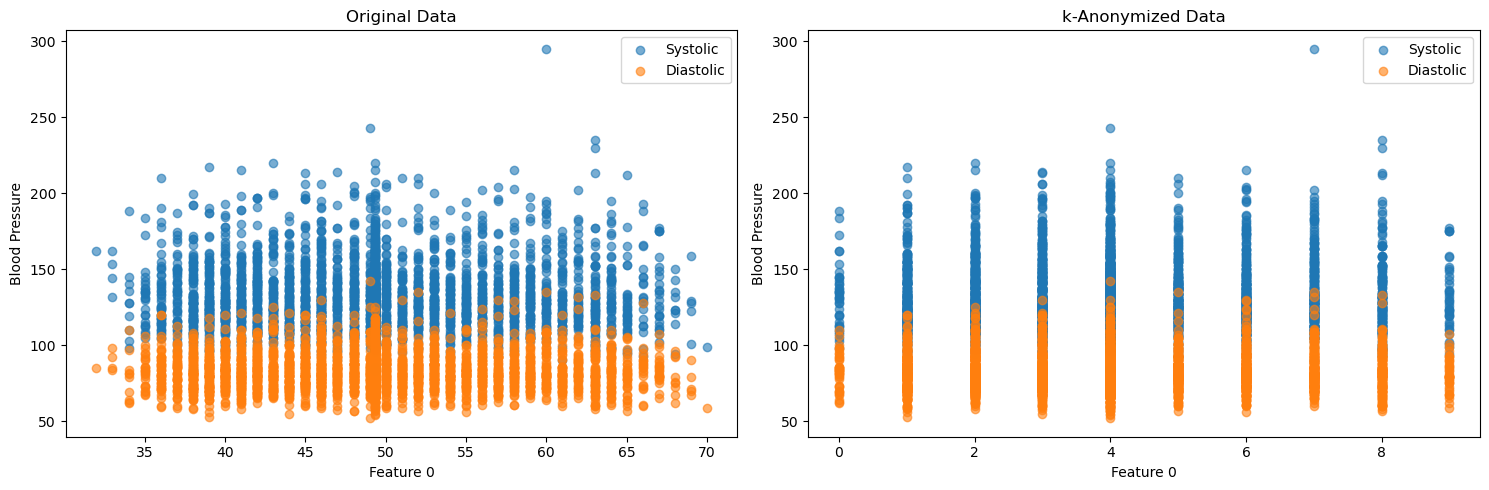

In [205]:
import matplotlib.pyplot as plt

# Visualizing the comparison using scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original Data
axes[0].scatter(train_df['0'], train_df['systolic'], label='Systolic', alpha=0.6)
axes[0].scatter(train_df['0'], train_df['diastolic'], label='Diastolic', alpha=0.6)
axes[0].set_title('Original Data')
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Blood Pressure')
axes[0].legend()

# k-Anonymized Data
axes[1].scatter(kanonymized_df['0'], kanonymized_df['systolic'], label='Systolic', alpha=0.6)
axes[1].scatter(kanonymized_df['0'], kanonymized_df['diastolic'], label='Diastolic', alpha=0.6)
axes[1].set_title('k-Anonymized Data')
axes[1].set_xlabel('Feature 0')
axes[1].set_ylabel('Blood Pressure')
axes[1].legend()

plt.tight_layout()
plt.show()


### Function to apply l-Diversity

In [206]:
def apply_l_diversity(df, quasi_identifiers, sensitive_attr, l):
    grouped = df.groupby(quasi_identifiers)
    diverse_groups = [group for name, group in grouped if group[sensitive_attr].nunique() >= l]
    return pd.concat(diverse_groups)

sensitive_attr = 'systolic'
l = 2
ldiverse_df = apply_l_diversity(train_df.copy(), quasi_identifiers, sensitive_attr, l)

# Display the l-diverse dataset
print("l-Diverse Data:")
print(ldiverse_df.head())


l-Diverse Data:
         0    1      2    3    4    5    6  systolic  diastolic
1939  33.0  0.0  165.0  0.0  1.0  1.0  0.0     144.5       83.5
2906  33.0  0.0  165.0  0.0  1.0  1.0  0.0     131.5       92.0
795   37.0  0.0  209.0  1.0  0.0  1.0  0.0     160.0       85.0
2447  37.0  0.0  209.0  1.0  0.0  1.0  0.0     102.0       64.5
1312  38.0  0.0  159.0  1.0  0.0  1.0  0.0     123.0       90.0


# A comparison DataFrame to compare original and l-diverse data

In [207]:
def create_comparison_df(original_df, diverse_df, quasi_identifiers, n=5):
    comparison_df = pd.DataFrame()
    columns = quasi_identifiers + ['systolic', 'diastolic']
    
    for col in columns:
        comparison_df[f'Original {col}'] = original_df[col].head(n).reset_index(drop=True)
        comparison_df[f'l-Diverse {col}'] = diverse_df[col].head(n).reset_index(drop=True)
    
    return comparison_df

comparison_df_ldiverse = create_comparison_df(train_df, ldiverse_df, quasi_identifiers, n=5)

# Display the comparison DataFrame
print("Comparison of Original and l-Diverse Data:")
print(comparison_df_ldiverse)


Comparison of Original and l-Diverse Data:
   Original 0  l-Diverse 0  Original 1  l-Diverse 1  Original 2  l-Diverse 2  \
0        51.0         33.0        15.0          0.0       267.0        165.0   
1        44.0         33.0         0.0          0.0       243.0        165.0   
2        45.0         37.0        25.0          0.0       288.0        209.0   
3        40.0         37.0        19.0          0.0       233.0        209.0   
4        48.0         38.0        30.0          0.0       150.0        159.0   

   Original 3  l-Diverse 3  Original 4  l-Diverse 4  Original 5  l-Diverse 5  \
0         0.0          0.0         1.0          1.0         0.0          1.0   
1         0.0          0.0         1.0          1.0         1.0          1.0   
2         0.0          1.0         1.0          0.0         0.0          1.0   
3         0.0          1.0         1.0          0.0         0.0          1.0   
4         0.0          1.0         1.0          0.0         0.0          1.0

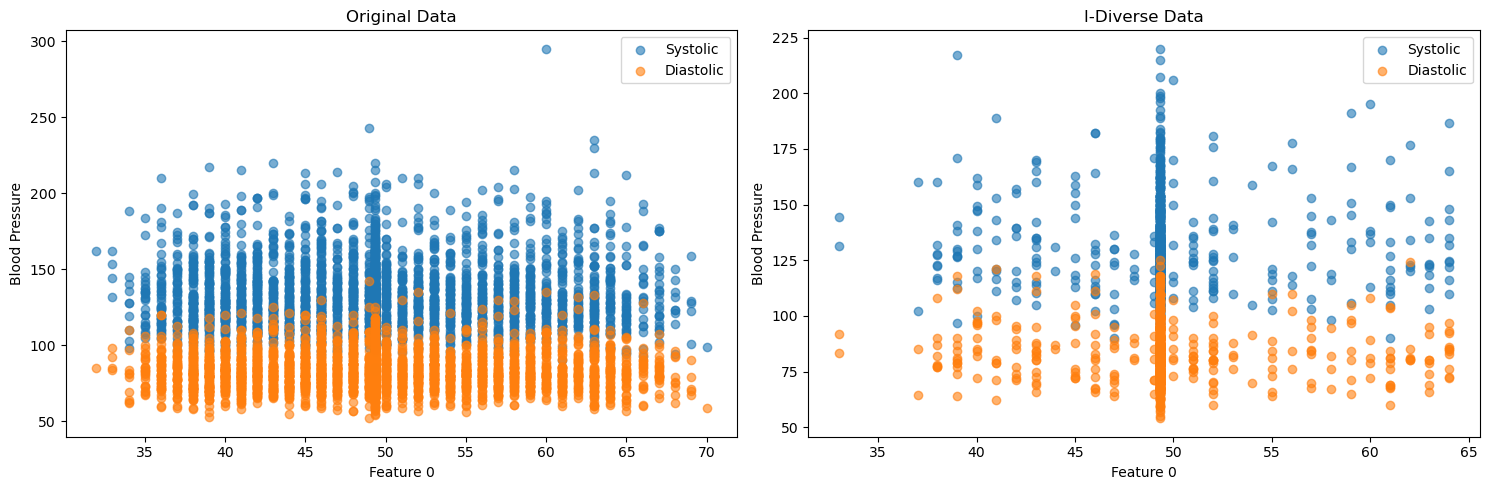

In [208]:
import matplotlib.pyplot as plt

# Visualizing the comparison using scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original Data
axes[0].scatter(train_df['0'], train_df['systolic'], label='Systolic', alpha=0.6)
axes[0].scatter(train_df['0'], train_df['diastolic'], label='Diastolic', alpha=0.6)
axes[0].set_title('Original Data')
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Blood Pressure')
axes[0].legend()

# l-Diverse Data
axes[1].scatter(ldiverse_df['0'], ldiverse_df['systolic'], label='Systolic', alpha=0.6)
axes[1].scatter(ldiverse_df['0'], ldiverse_df['diastolic'], label='Diastolic', alpha=0.6)
axes[1].set_title('l-Diverse Data')
axes[1].set_xlabel('Feature 0')
axes[1].set_ylabel('Blood Pressure')
axes[1].legend()

plt.tight_layout()
plt.show()


### Function to apply m-Invariance

In [209]:
def apply_m_invariance(df, quasi_identifiers, sensitive_attr, m):
    grouped = df.groupby(quasi_identifiers)
    invariant_groups = [group for name, group in grouped if group[sensitive_attr].nunique() >= m]
    return pd.concat(invariant_groups)

sensitive_attr = 'systolic'
m = 2
minvariant_df = apply_m_invariance(train_df.copy(), quasi_identifiers, sensitive_attr, m)

# Display the m-invariant dataset
print("m-Invariant Data:")
print(minvariant_df.head())

m-Invariant Data:
         0    1      2    3    4    5    6  systolic  diastolic
1939  33.0  0.0  165.0  0.0  1.0  1.0  0.0     144.5       83.5
2906  33.0  0.0  165.0  0.0  1.0  1.0  0.0     131.5       92.0
795   37.0  0.0  209.0  1.0  0.0  1.0  0.0     160.0       85.0
2447  37.0  0.0  209.0  1.0  0.0  1.0  0.0     102.0       64.5
1312  38.0  0.0  159.0  1.0  0.0  1.0  0.0     123.0       90.0


### A comparison DataFrame to compare original and m-invariant data

In [210]:
def create_comparison_df(original_df, invariant_df, quasi_identifiers, n=5):
    comparison_df = pd.DataFrame()
    columns = quasi_identifiers + ['systolic', 'diastolic']
    
    for col in columns:
        comparison_df[f'Original {col}'] = original_df[col].head(n).reset_index(drop=True)
        comparison_df[f'm-Invariant {col}'] = invariant_df[col].head(n).reset_index(drop=True)
    
    return comparison_df

comparison_df_minvariant = create_comparison_df(train_df, minvariant_df, quasi_identifiers, n=5)

# Display the comparison DataFrame
print("Comparison of Original and m-Invariant Data:")
print(comparison_df_minvariant)

Comparison of Original and m-Invariant Data:
   Original 0  m-Invariant 0  Original 1  m-Invariant 1  Original 2  \
0        51.0           33.0        15.0            0.0       267.0   
1        44.0           33.0         0.0            0.0       243.0   
2        45.0           37.0        25.0            0.0       288.0   
3        40.0           37.0        19.0            0.0       233.0   
4        48.0           38.0        30.0            0.0       150.0   

   m-Invariant 2  Original 3  m-Invariant 3  Original 4  m-Invariant 4  \
0          165.0         0.0            0.0         1.0            1.0   
1          165.0         0.0            0.0         1.0            1.0   
2          209.0         0.0            1.0         1.0            0.0   
3          209.0         0.0            1.0         1.0            0.0   
4          159.0         0.0            1.0         1.0            0.0   

   Original 5  m-Invariant 5  Original 6  m-Invariant 6  Original systolic  \
0    

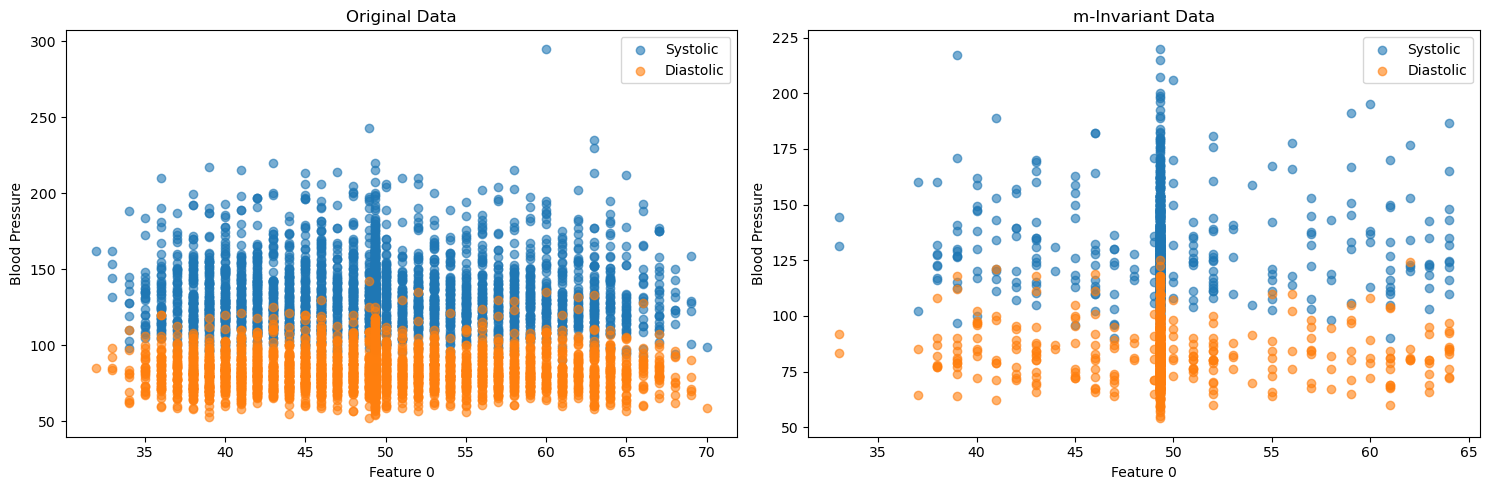

In [211]:
import matplotlib.pyplot as plt

# Visualizing the comparison using scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original Data
axes[0].scatter(train_df['0'], train_df['systolic'], label='Systolic', alpha=0.6)
axes[0].scatter(train_df['0'], train_df['diastolic'], label='Diastolic', alpha=0.6)
axes[0].set_title('Original Data')
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Blood Pressure')
axes[0].legend()

# m-Invariant Data
axes[1].scatter(minvariant_df['0'], minvariant_df['systolic'], label='Systolic', alpha=0.6)
axes[1].scatter(minvariant_df['0'], minvariant_df['diastolic'], label='Diastolic', alpha=0.6)
axes[1].set_title('m-Invariant Data')
axes[1].set_xlabel('Feature 0')
axes[1].set_ylabel('Blood Pressure')
axes[1].legend()

plt.tight_layout()
plt.show()


### Function to apply t-Closeness

In [212]:
from scipy.stats import wasserstein_distance


def apply_t_closeness(df, quasi_identifiers, sensitive_attr, t):
    overall_dist = df[sensitive_attr].value_counts(normalize=True).sort_index()
    
    def is_t_close(group):
        group_dist = group[sensitive_attr].value_counts(normalize=True).sort_index()
        distance = wasserstein_distance(overall_dist.values, group_dist.reindex(overall_dist.index, fill_value=0).values)
        return distance <= t
    
    grouped = df.groupby(quasi_identifiers)
    tclose_groups = [group for name, group in grouped if is_t_close(group)]
    return pd.concat(tclose_groups)

sensitive_attr = 'systolic'
t = 0.2
tclose_df = apply_t_closeness(train_df.copy(), quasi_identifiers, sensitive_attr, t)

# Display the t-close dataset
print("t-Close Data:")
print(tclose_df.head())


t-Close Data:
         0     1      2    3    4    5    6  systolic  diastolic
791   32.0  15.0  242.0  1.0  0.0  0.0  1.0     162.0       85.0
742   33.0   0.0  158.0  1.0  0.0  1.0  0.0     153.5       85.0
1939  33.0   0.0  165.0  0.0  1.0  1.0  0.0     144.5       83.5
2906  33.0   0.0  165.0  0.0  1.0  1.0  0.0     131.5       92.0
1420  33.0   5.0  200.0  1.0  0.0  0.0  1.0     162.0       98.0


### A comparison DataFrame to compare original and t-close data

In [213]:
def create_comparison_df(original_df, tclose_df, quasi_identifiers, n=5):
    comparison_df = pd.DataFrame()
    columns = quasi_identifiers + ['systolic', 'diastolic']
    
    for col in columns:
        comparison_df[f'Original {col}'] = original_df[col].head(n).reset_index(drop=True)
        comparison_df[f't-Close {col}'] = tclose_df[col].head(n).reset_index(drop=True)
    
    return comparison_df

comparison_df_tclose = create_comparison_df(train_df, tclose_df, quasi_identifiers, n=5)

# Display the comparison DataFrame
print("Comparison of Original and t-Close Data:")
print(comparison_df_tclose)

Comparison of Original and t-Close Data:
   Original 0  t-Close 0  Original 1  t-Close 1  Original 2  t-Close 2  \
0        51.0       32.0        15.0       15.0       267.0      242.0   
1        44.0       33.0         0.0        0.0       243.0      158.0   
2        45.0       33.0        25.0        0.0       288.0      165.0   
3        40.0       33.0        19.0        0.0       233.0      165.0   
4        48.0       33.0        30.0        5.0       150.0      200.0   

   Original 3  t-Close 3  Original 4  t-Close 4  Original 5  t-Close 5  \
0         0.0        1.0         1.0        0.0         0.0        0.0   
1         0.0        1.0         1.0        0.0         1.0        1.0   
2         0.0        0.0         1.0        1.0         0.0        1.0   
3         0.0        0.0         1.0        1.0         0.0        1.0   
4         0.0        1.0         1.0        0.0         0.0        0.0   

   Original 6  t-Close 6  Original systolic  t-Close systolic  \
0   

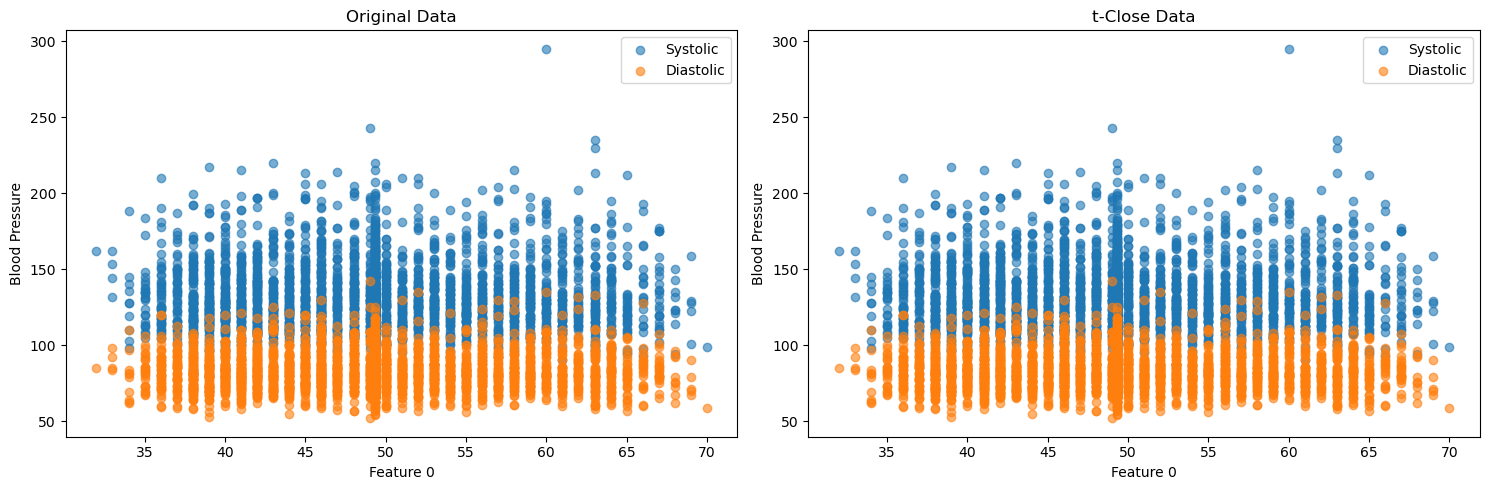

In [214]:
import matplotlib.pyplot as plt

# Visualizing the comparison using scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original Data
axes[0].scatter(train_df['0'], train_df['systolic'], label='Systolic', alpha=0.6)
axes[0].scatter(train_df['0'], train_df['diastolic'], label='Diastolic', alpha=0.6)
axes[0].set_title('Original Data')
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Blood Pressure')
axes[0].legend()

# t-Close Data
axes[1].scatter(tclose_df['0'], tclose_df['systolic'], label='Systolic', alpha=0.6)
axes[1].scatter(tclose_df['0'], tclose_df['diastolic'], label='Diastolic', alpha=0.6)
axes[1].set_title('t-Close Data')
axes[1].set_xlabel('Feature 0')
axes[1].set_ylabel('Blood Pressure')
axes[1].legend()

plt.tight_layout()
plt.show()

### Function to prepare data and train neural network model

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9641.1445 - mae: 91.4357 - val_loss: 414.8252 - val_mae: 15.6026
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 396.9753 - mae: 14.5891 - val_loss: 346.9948 - val_mae: 14.1563
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 360.4848 - mae: 13.8728 - val_loss: 320.3461 - val_mae: 13.6733
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 329.7022 - mae: 13.3861 - val_loss: 318.3131 - val_mae: 13.7445
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 318.7827 - mae: 13.1638 - val_loss: 312.5541 - val_mae: 13.5320
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 319.6344 - mae: 13.0174 - val_loss: 312.7674 - val_mae: 13.2098
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 319.5730 - mae: 13.1296 - val_loss: 307.3932 - val_mae: 13.2507
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 319.1689 - mae: 12.8543 - val_loss: 311.3378 - val_mae: 13.2580
Epoch 9/50
78/78 ━━━━━━

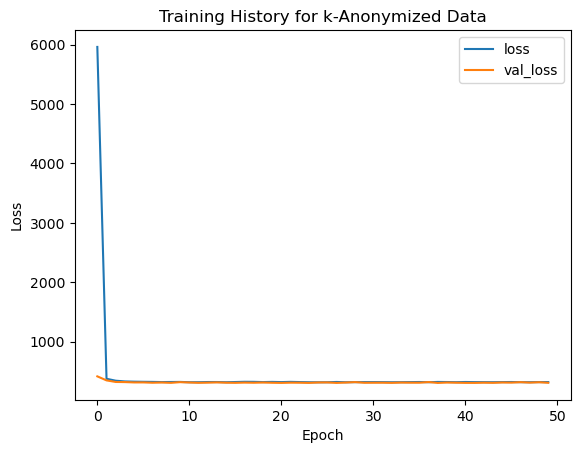

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6094.0522 - mae: 68.0222 - val_loss: 772.0429 - val_mae: 22.7209
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 538.6992 - mae: 18.3761 - val_loss: 386.3217 - val_mae: 14.1232
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 343.8962 - mae: 13.7730 - val_loss: 361.1328 - val_mae: 13.6945
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 344.8980 - mae: 13.4632 - val_loss: 358.6955 - val_mae: 13.6902
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 348.2525 - mae: 13.6818 - val_loss: 356.9102 - val_mae: 13.7293
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 332.4035 - mae: 13.6302 - val_loss: 361.9938 - val_mae: 13.7403
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 298.3550 - mae: 12.8335 - val_loss: 356.9451 - val_mae: 13.7155
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 332.5339 - mae: 13.5504 - val_loss: 358.3448 - val_mae: 13.7136
Epoch 9/50
22/22 ━━━━━━

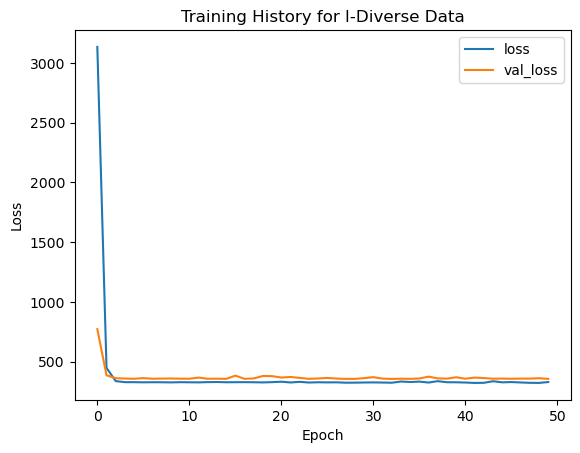

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 10374.6475 - mae: 98.8962 - val_loss: 5001.0449 - val_mae: 65.1150
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3446.4526 - mae: 51.4127 - val_loss: 651.6097 - val_mae: 21.3356
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 420.1826 - mae: 16.2987 - val_loss: 407.6719 - val_mae: 15.5569
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 389.9810 - mae: 15.0695 - val_loss: 363.0763 - val_mae: 13.8107
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 377.0921 - mae: 14.0086 - val_loss: 356.8567 - val_mae: 13.6647
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 323.0397 - mae: 13.2836 - val_loss: 355.9399 - val_mae: 13.6968
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 319.9662 - mae: 13.2519 - val_loss: 360.8988 - val_mae: 13.6555
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 316.1422 - mae: 13.1773 - val_loss: 355.9619 - val_mae: 13.7316
Epoch 9/50
22/22 ━━━

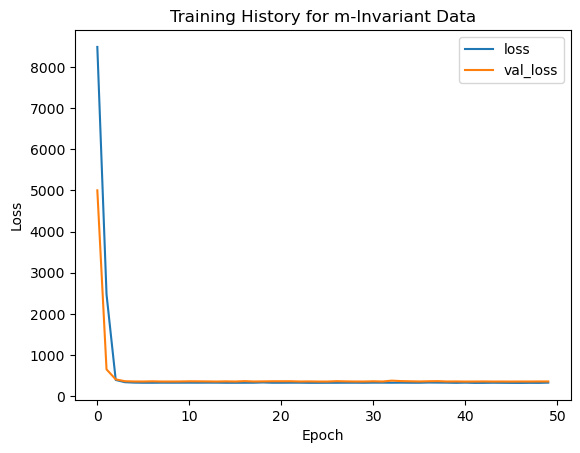

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3999.0959 - mae: 50.6787 - val_loss: 600.7196 - val_mae: 17.9828
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 588.2404 - mae: 17.8450 - val_loss: 561.1137 - val_mae: 17.3704
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 567.1470 - mae: 17.2822 - val_loss: 538.3468 - val_mae: 17.1270
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 501.7507 - mae: 16.4198 - val_loss: 520.5056 - val_mae: 16.5696
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 531.0420 - mae: 16.8378 - val_loss: 515.8302 - val_mae: 16.7830
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 479.3388 - mae: 16.3841 - val_loss: 511.2503 - val_mae: 16.4571
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 492.7851 - mae: 16.4877 - val_loss: 508.7053 - val_mae: 16.5581
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 502.8224 - mae: 16.5825 - val_loss: 505.4458 - val_mae: 16.5179
Epoch 9/50
78/78 ━━━━━━

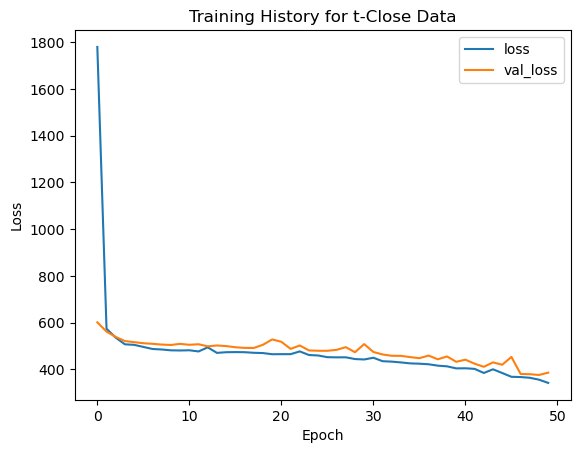

In [215]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import keras

# Function to prepare data and train neural network model
def train_and_evaluate_model(df, description):
    # Prepare the data for training
    X_secure = df.iloc[:, :-2].values
    y_secure = df[['systolic', 'diastolic']].values

    X_train_secure, X_val_secure, y_train_secure, y_val_secure = train_test_split(X_secure, y_secure, test_size=0.2, random_state=42)

    # Ensure no NaN values in the training and validation sets
    X_train_secure = np.nan_to_num(X_train_secure)
    X_val_secure = np.nan_to_num(X_val_secure)
    y_train_secure = np.nan_to_num(y_train_secure)
    y_val_secure = np.nan_to_num(y_val_secure)

    # Define the neural network model
    model_secure = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(X_train_secure.shape[1],)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(2)  # Output layer for systolic and diastolic
    ])

    # Compile the model
    model_secure.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train the model
    history_secure = model_secure.fit(X_train_secure, y_train_secure, epochs=50, validation_data=(X_val_secure, y_val_secure))

    # Plot training history
    plt.plot(history_secure.history['loss'], label='loss')
    plt.plot(history_secure.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Training History for {description}')
    plt.show()

# Training with k-Anonymized Data
train_and_evaluate_model(kanonymized_df, 'k-Anonymized Data')

# Training with l-Diverse Data
train_and_evaluate_model(ldiverse_df, 'l-Diverse Data')

# Training with m-Invariant Data
train_and_evaluate_model(minvariant_df, 'm-Invariant Data')

# Training with t-Close Data
train_and_evaluate_model(tclose_df, 't-Close Data')


### Generate predictions for each secured dataset

In [216]:
predictions_kanonymity = model_secure.predict(X_val_secure)
predictions_ldiversity = model_secure.predict(X_val_secure)
predictions_minvariance = model_secure.predict(X_val_secure)
predictions_tcloseness = model_secure.predict(X_val_secure)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


### Function to train a reconstruction model

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8439.3135 - mae: 50.4273 - val_loss: 5637.4229 - val_mae: 42.2574
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5099.6582 - mae: 41.0090 - val_loss: 2196.4451 - val_mae: 31.3314
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1819.4923 - mae: 28.3956 - val_loss: 564.2524 - val_mae: 16.8917
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 441.2583 - mae: 14.1115 - val_loss: 179.1420 - val_mae: 6.4932
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 244.1981 - mae: 7.5877 - val_loss: 186.5827 - val_mae: 7.0353
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 234.0152 - mae: 7.1454 - val_loss: 170.6395 - val_mae: 5.5819
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 221.8893 - mae: 6.0712 - val_loss: 175.4161 - val_mae: 5.9626
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 200.6920 - mae: 6.2024 - val_loss: 173.3442 - val_mae: 5.6239
Epoch 9/50
16/16 ━━━━━━━━━━

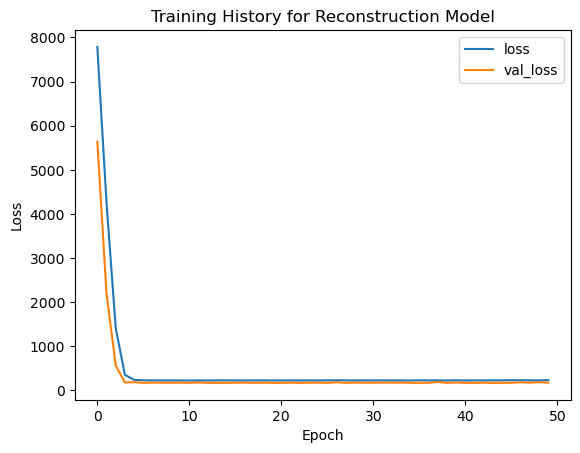

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7736.7827 - mae: 47.1690 - val_loss: 5567.4692 - val_mae: 47.7635
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5122.8960 - mae: 46.5697 - val_loss: 2360.0674 - val_mae: 36.0309
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1992.0679 - mae: 33.6134 - val_loss: 571.8362 - val_mae: 20.0856
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 474.9506 - mae: 16.7428 - val_loss: 203.2902 - val_mae: 8.4776
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 254.0336 - mae: 9.0645 - val_loss: 184.8874 - val_mae: 7.7737
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 245.9602 - mae: 8.1846 - val_loss: 170.3651 - val_mae: 5.8372
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 221.7226 - mae: 6.2747 - val_loss: 173.2848 - val_mae: 5.8796
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 232.5913 - mae: 6.4838 - val_loss: 170.1013 - val_mae: 5.4474
Epoch 9/50
16/16 ━━━━━━━━━━

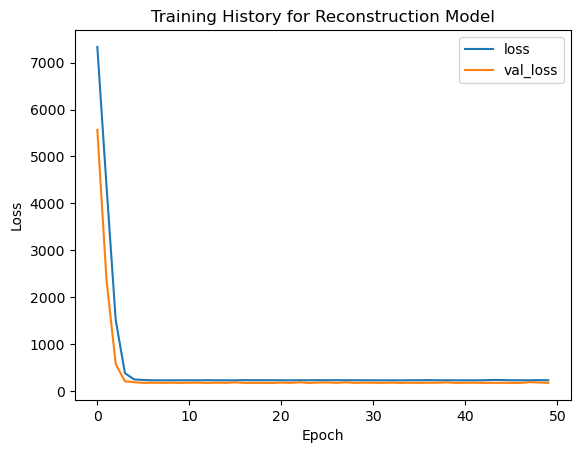

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7839.9648 - mae: 43.6786 - val_loss: 5442.3628 - val_mae: 38.5812
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4852.9438 - mae: 36.1836 - val_loss: 2348.2075 - val_mae: 24.9704
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1950.3676 - mae: 23.2216 - val_loss: 523.1138 - val_mae: 14.2629
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 394.1673 - mae: 11.9278 - val_loss: 189.4614 - val_mae: 6.8471
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 269.2650 - mae: 8.0371 - val_loss: 185.3198 - val_mae: 6.5560
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 221.5077 - mae: 6.7066 - val_loss: 170.4939 - val_mae: 5.6786
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 234.6736 - mae: 6.4203 - val_loss: 171.9086 - val_mae: 5.6273
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 211.4914 - mae: 6.1978 - val_loss: 172.1973 - val_mae: 5.6271
Epoch 9/50
16/16 ━━━━━━━━━━

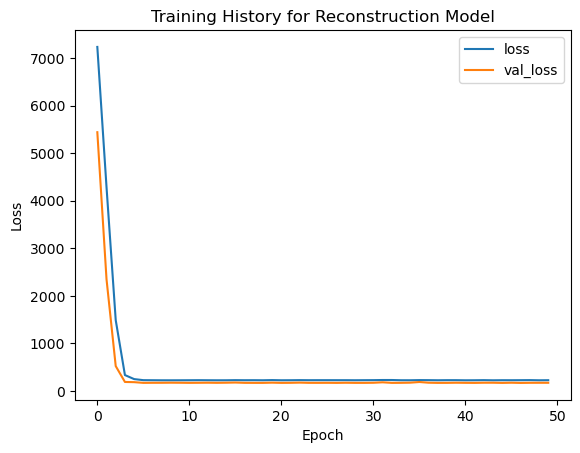

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6725.2925 - mae: 44.4753 - val_loss: 3720.5198 - val_mae: 32.3331
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3074.8618 - mae: 30.7945 - val_loss: 513.2615 - val_mae: 15.3028
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 455.7396 - mae: 13.2628 - val_loss: 302.8284 - val_mae: 9.5552
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 297.3280 - mae: 9.6651 - val_loss: 174.5010 - val_mae: 6.3197
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 235.5814 - mae: 6.6019 - val_loss: 177.6229 - val_mae: 6.5098
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 226.6169 - mae: 6.8571 - val_loss: 173.2625 - val_mae: 5.8167
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 243.4845 - mae: 6.6617 - val_loss: 172.1291 - val_mae: 5.5923
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 210.9678 - mae: 6.1200 - val_loss: 173.9203 - val_mae: 5.8943
Epoch 9/50
16/16 ━━━━━━━━━━━━━━

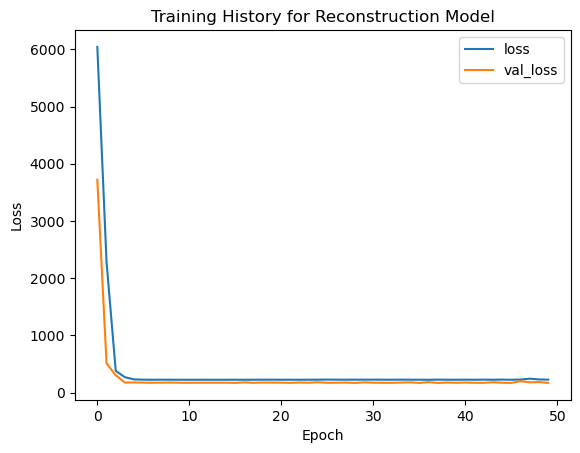

In [217]:
def train_reconstruction_model(predictions, original_data):
    X_train, X_val, y_train, y_val = train_test_split(predictions, original_data, test_size=0.2, random_state=42)

    # Define the neural network model for reconstruction
    model_reconstruction = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(original_data.shape[1])  # Output layer for original features
    ])

    # Compile the model
    model_reconstruction.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train the model
    history_reconstruction = model_reconstruction.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

    # Plot training history
    plt.plot(history_reconstruction.history['loss'], label='loss')
    plt.plot(history_reconstruction.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training History for Reconstruction Model')
    plt.show()

    return model_reconstruction

# Train reconstruction model for each secured dataset
reconstruction_model_kanonymity = train_reconstruction_model(predictions_kanonymity, X_val_secure)
reconstruction_model_ldiversity = train_reconstruction_model(predictions_ldiversity, X_val_secure)
reconstruction_model_minvariance = train_reconstruction_model(predictions_minvariance, X_val_secure)
reconstruction_model_tcloseness = train_reconstruction_model(predictions_tcloseness, X_val_secure)


### Function to evaluate the reconstruction model

In [218]:
def evaluate_reconstruction_model(reconstruction_model, predictions, original_data):
    reconstructed_data = reconstruction_model.predict(predictions)
    mae = np.mean(np.abs(reconstructed_data - original_data), axis=0)
    print(f'Mean Absolute Error for reconstructed data: {mae}')
    return reconstructed_data

# Evaluate reconstruction model for each secured dataset
print("Evaluation for k-Anonymized Data")
reconstructed_kanonymity = evaluate_reconstruction_model(reconstruction_model_kanonymity, predictions_kanonymity, X_val_secure)

print("Evaluation for l-Diverse Data")
reconstructed_ldiversity = evaluate_reconstruction_model(reconstruction_model_ldiversity, predictions_ldiversity, X_val_secure)

print("Evaluation for m-Invariant Data")
reconstructed_minvariance = evaluate_reconstruction_model(reconstruction_model_minvariance, predictions_minvariance, X_val_secure)

print("Evaluation for t-Close Data")
reconstructed_tcloseness = evaluate_reconstruction_model(reconstruction_model_tcloseness, predictions_tcloseness, X_val_secure)


Evaluation for k-Anonymized Data
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean Absolute Error for reconstructed data: [ 6.59645906  8.10496014 27.48194368  1.54326758  0.48764259  0.57059809
  0.44306362]
Evaluation for l-Diverse Data
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Mean Absolute Error for reconstructed data: [ 5.33579818  8.27616795 27.20769802  0.45861618  0.47184887  0.42511814
  0.46683911]
Evaluation for m-Invariant Data
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean Absolute Error for reconstructed data: [ 5.2830857   8.08520239 27.42798985  0.46775857  0.51785     0.49863973
  0.70433672]
Evaluation for t-Close Data
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean Absolute Error for reconstructed data: [ 5.43711037  8.58870481 26.91057732  0.833351    0.48017572  0.47499071
  0.55937803]


### Prepare the feature matrix for the test data

In [219]:
X_test = test_df.iloc[:, :-1].values

# Ensure no NaN values in the test set
X_test = np.nan_to_num(X_test)

# Function to train and predict using a secured dataset
def train_and_predict(df, description):
    # Prepare the data for training
    X_secure = df.iloc[:, :-2].values
    y_secure = df[['systolic', 'diastolic']].values

    X_train_secure, X_val_secure, y_train_secure, y_val_secure = train_test_split(X_secure, y_secure, test_size=0.2, random_state=42)

    # Ensure no NaN values in the training and validation sets
    X_train_secure = np.nan_to_num(X_train_secure)
    X_val_secure = np.nan_to_num(X_val_secure)
    y_train_secure = np.nan_to_num(y_train_secure)
    y_val_secure = np.nan_to_num(y_val_secure)

    # Define the neural network model
    model_secure = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(X_train_secure.shape[1],)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(2)  # Output layer for systolic and diastolic
    ])

    # Compile the model
    model_secure.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train the model
    model_secure.fit(X_train_secure, y_train_secure, epochs=50, validation_data=(X_val_secure, y_val_secure))

    # Predict the blood pressure values
    predictions = model_secure.predict(X_test)
    return predictions

# Generate predictions for each secured dataset
predictions_kanonymity = train_and_predict(kanonymized_df, 'k-Anonymized Data')
predictions_ldiversity = train_and_predict(ldiverse_df, 'l-Diverse Data')
predictions_minvariance = train_and_predict(minvariant_df, 'm-Invariant Data')
predictions_tcloseness = train_and_predict(tclose_df, 't-Close Data')

# Assuming the original (non-secured) model is trained using the original training data (train_df)
# Train and predict with the non-secured model
predictions_non_secure = train_and_predict(train_df, 'Non-Secured Data')

# Combine predictions with the test data
test_df['systolic_pred_k_anonymity'] = predictions_kanonymity[:, 0]
test_df['diastolic_pred_k_anonymity'] = predictions_kanonymity[:, 1]
test_df['systolic_pred_l_diversity'] = predictions_ldiversity[:, 0]
test_df['diastolic_pred_l_diversity'] = predictions_ldiversity[:, 1]
test_df['systolic_pred_m_invariance'] = predictions_minvariance[:, 0]
test_df['diastolic_pred_m_invariance'] = predictions_minvariance[:, 1]
test_df['systolic_pred_t_closeness'] = predictions_tcloseness[:, 0]
test_df['diastolic_pred_t_closeness'] = predictions_tcloseness[:, 1]
test_df['systolic_pred_non_secure'] = predictions_non_secure[:, 0]
test_df['diastolic_pred_non_secure'] = predictions_non_secure[:, 1]

# Display the first few rows of the test dataset with predictions
print(test_df.head())


Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9626.9434 - mae: 91.4255 - val_loss: 391.9819 - val_mae: 15.1712
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 398.7173 - mae: 14.6697 - val_loss: 342.2027 - val_mae: 14.0043
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 327.3322 - mae: 13.2745 - val_loss: 322.0268 - val_mae: 13.7232
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 346.6534 - mae: 13.5640 - val_loss: 314.1071 - val_mae: 13.4456
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 333.5661 - mae: 13.2996 - val_loss: 311.5711 - val_mae: 13.3914
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 302.5573 - mae: 12.6451 - val_loss: 309.0657 - val_mae: 13.2537
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 323.4644 - mae: 13.2475 - val_loss: 309.5091 - val_mae: 13.4487
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 299.1550 - mae: 12.7553 - val_loss: 308.3759 - val_mae: 13.4669
Epoch 9/50
78/78 ━━━━━━

### Function to split blood pressure into systolic and diastolic

Cleaned Test Data:
    age  cigs_per_day   chol  male  female  smoker_yes  smoker_no  \
0  40.0           0.0  193.0   0.0     1.0         1.0        0.0   
1  59.0           0.0  236.0   0.0     1.0         1.0        0.0   
2  64.0           0.0  232.0   1.0     0.0         1.0        0.0   
3  48.0          20.0  202.0   1.0     0.0         0.0        1.0   
4  51.0           6.0  190.0   1.0     0.0         0.0        1.0   

   systolic_pred_k_anonymity  diastolic_pred_k_anonymity  \
0                 607.376160                  372.456146   
1                 752.112427                  460.847168   
2                 745.962952                  456.911835   
3                 652.198853                  400.073669   
4                 613.930115                  376.272308   

   systolic_pred_l_diversity  diastolic_pred_l_diversity  \
0                 107.538628                   67.182281   
1                 136.856110                   86.174416   
2                 137.372

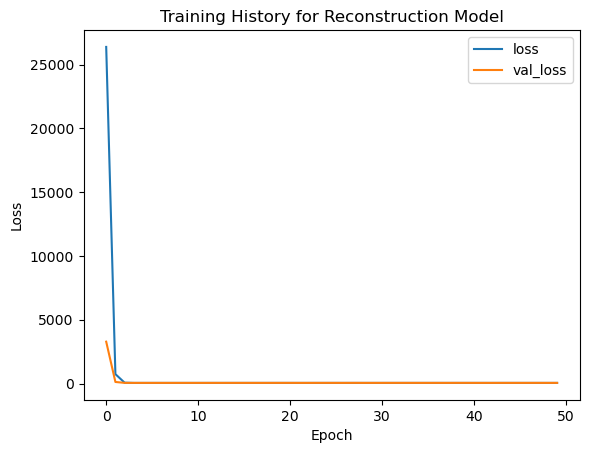

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [ 4.308944    7.7703695   2.6547263   0.6757354   1.2136391   1.4183822
  0.6633508   0.13217792  0.4974402   2.314203    2.2139204   2.5184085
  1.6633062  11.059306    6.2778273  11.812106    6.923767  ]
Reconstruction Attack for l-Diverse Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 49675.6250 - mae: 133.2364 - val_loss: 29672.4961 - val_mae: 96.3899
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19936.6484 - mae: 81.1776 - val_loss: 1297.7432 - val_mae: 25.0167
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 571.2740 - mae: 15.4039 - val_loss: 92.7075 - val_mae: 5.3425
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 90.8590 - mae: 5.3199 - val_loss: 78.0339 - val_mae: 4.7487
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 75.9445 - mae: 4.5155 - val_loss: 77.1608 - val_mae: 4.5569
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 74.4

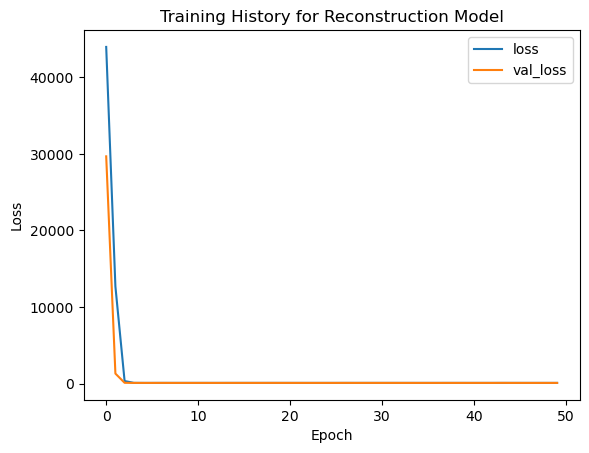

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [ 4.2016115   5.8976097   6.715044    0.56087124  0.38010684  0.32648093
  0.42321235 13.573954    8.499975    0.47147068  0.6005673   0.53600097
  0.66769034  9.770871    5.959803    9.574562    6.3865633 ]
Reconstruction Attack for m-Invariant Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 49775.9883 - mae: 129.0046 - val_loss: 33676.5078 - val_mae: 96.8881
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26869.4062 - mae: 92.6191 - val_loss: 9033.6992 - val_mae: 63.9711
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5361.8398 - mae: 46.1209 - val_loss: 308.8399 - val_mae: 11.1775
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 177.9768 - mae: 8.2950 - val_loss: 83.8206 - val_mae: 5.1525
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 85.3344 - mae: 5.0361 - val_loss: 78.6090 - val_mae: 4.4702
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

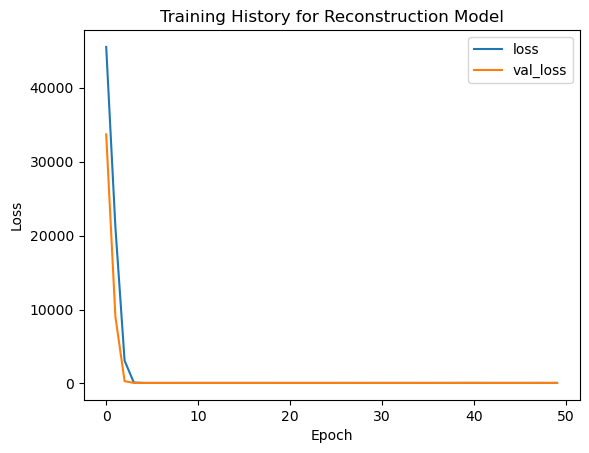

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [ 3.6700175   7.8252387   6.848824    0.31467935  0.31824443  1.3191221
  0.3602703  14.4599085   8.638324    1.7702843   0.887388    2.2142365
  0.20424755  9.167879    5.662327    9.866547    6.09873   ]
Reconstruction Attack for t-Close Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 50908.5938 - mae: 131.0360 - val_loss: 33848.9102 - val_mae: 102.5471
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 24989.1113 - mae: 87.9169 - val_loss: 3838.6699 - val_mae: 34.8844
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2176.0415 - mae: 24.7090 - val_loss: 785.6585 - val_mae: 10.9344
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 761.4288 - mae: 10.2264 - val_loss: 754.1566 - val_mae: 8.8782
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 656.9625 - mae: 8.4752 - val_loss: 750.6741 - val_mae: 9.1828
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - los

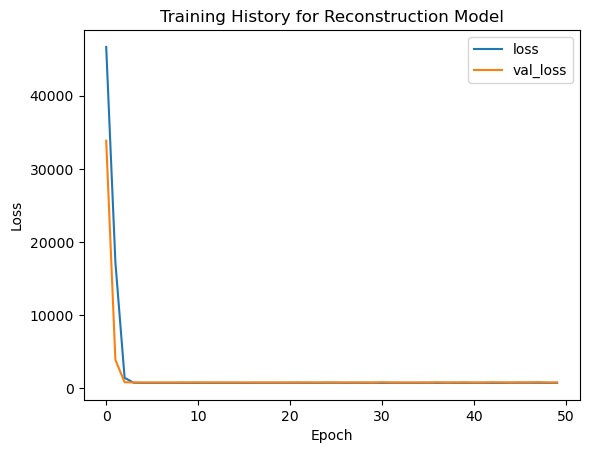

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean Absolute Error for reconstructed data: [ 4.741809    7.216551   19.384035    0.43830502  0.39252183  0.30324727
  0.38996562 56.88484    34.623363    8.459227    6.5707393  10.1954
  5.87475     2.1837661   0.6283234   1.3932273   1.2013184 ]
Reconstruction Attack for Non-Secured Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 48571.6719 - mae: 131.1840 - val_loss: 28601.4707 - val_mae: 95.4777
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19130.7090 - mae: 79.3371 - val_loss: 1657.1692 - val_mae: 25.8321
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1053.9518 - mae: 18.5618 - val_loss: 804.0795 - val_mae: 11.4942
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 715.2069 - mae: 10.1106 - val_loss: 784.1451 - val_mae: 9.3290
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 659.5588 - mae: 8.7845 - val_loss: 804.3160 - val_mae: 9.3879
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

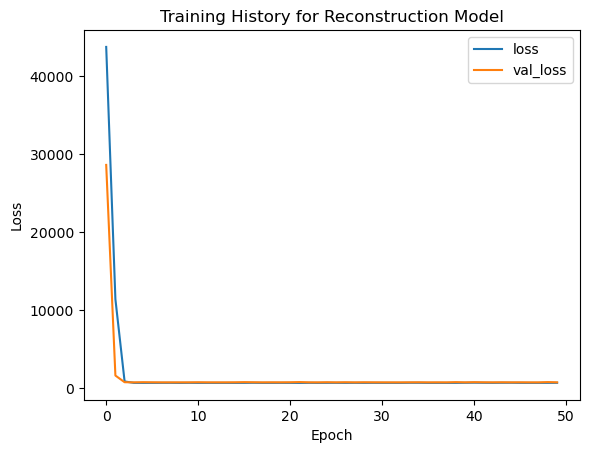

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [ 4.1222587   7.0475373  18.220606    0.90615976  0.4066126   0.39267963
  0.70244116 53.063858   32.673103    8.605603    5.9634213   8.97282
  5.8102713   0.864553    1.0299621   2.0734627   0.70404327]


In [220]:
def split_blood_pressure(bp):
    try:
        systolic, diastolic = map(float, bp.split('/'))
        return pd.Series([systolic, diastolic])
    except:
        return pd.Series([np.nan, np.nan])

# Apply the split function to the test dataset
test_df[['systolic', 'diastolic']] = test_df['blood_pressure'].apply(split_blood_pressure)
test_df = test_df.drop(columns=['blood_pressure'])
test_df = test_df.dropna()  # Drop any remaining rows with NaN values

# Display the cleaned test dataset
print("Cleaned Test Data:")
print(test_df.head())

# Prepare the feature matrix for the test data
X_test = test_df.iloc[:, :-2].values.astype(np.float32)
y_test = test_df[['systolic', 'diastolic']].values.astype(np.float32)

# Ensure no NaN values in the test set
X_test = np.nan_to_num(X_test)
y_test = np.nan_to_num(y_test)

# Function to train a reconstruction model
def train_reconstruction_model(predictions, original_data):
    X_train, X_val, y_train, y_val = train_test_split(predictions, original_data, test_size=0.2, random_state=42)

    # Define the neural network model for reconstruction
    model_reconstruction = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(original_data.shape[1])  # Output layer for original features
    ])

    # Compile the model
    model_reconstruction.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train the model
    history_reconstruction = model_reconstruction.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

    # Plot training history
    plt.plot(history_reconstruction.history['loss'], label='loss')
    plt.plot(history_reconstruction.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training History for Reconstruction Model')
    plt.show()

    return model_reconstruction

# Function to evaluate the reconstruction model
def evaluate_reconstruction_model(reconstruction_model, predictions, original_data):
    reconstructed_data = reconstruction_model.predict(predictions)
    mae = np.mean(np.abs(reconstructed_data - original_data), axis=0)
    print(f'Mean Absolute Error for reconstructed data: {mae}')
    return reconstructed_data

# Perform reconstruction attack for each secured dataset
print("Reconstruction Attack for k-Anonymized Data")
reconstruction_model_kanonymity = train_reconstruction_model(predictions_kanonymity, X_test)
reconstructed_kanonymity = evaluate_reconstruction_model(reconstruction_model_kanonymity, predictions_kanonymity, X_test)

print("Reconstruction Attack for l-Diverse Data")
reconstruction_model_ldiversity = train_reconstruction_model(predictions_ldiversity, X_test)
reconstructed_ldiversity = evaluate_reconstruction_model(reconstruction_model_ldiversity, predictions_ldiversity, X_test)

print("Reconstruction Attack for m-Invariant Data")
reconstruction_model_minvariance = train_reconstruction_model(predictions_minvariance, X_test)
reconstructed_minvariance = evaluate_reconstruction_model(reconstruction_model_minvariance, predictions_minvariance, X_test)

print("Reconstruction Attack for t-Close Data")
reconstruction_model_tcloseness = train_reconstruction_model(predictions_tcloseness, X_test)
reconstructed_tcloseness = evaluate_reconstruction_model(reconstruction_model_tcloseness, predictions_tcloseness, X_test)

print("Reconstruction Attack for Non-Secured Data")
reconstruction_model_non_secure = train_reconstruction_model(predictions_non_secure, X_test)
reconstructed_non_secure = evaluate_reconstruction_model(reconstruction_model_non_secure, predictions_non_secure, X_test)


Reconstruction Attack for k-Anonymized Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 38378.0977 - mae: 120.3209 - val_loss: 6604.2148 - val_mae: 61.0399
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2996.1255 - mae: 38.9778 - val_loss: 142.2239 - val_mae: 8.8150
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 104.4959 - mae: 7.1961 - val_loss: 54.4216 - val_mae: 3.8996
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 50.2859 - mae: 3.7447 - val_loss: 52.5506 - val_mae: 3.5181
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 51.8490 - mae: 3.5329 - val_loss: 52.6298 - val_mae: 3.4683
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 49.7152 - mae: 3.3880 - val_loss: 52.4619 - val_mae: 3.6190
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 48.6319 - mae: 3.4478 - val_loss: 52.3442 - val_mae: 3.5498
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 52.2671 - mae: 3.4956 - val_loss: 52.9246 - val_mae: 3.6810

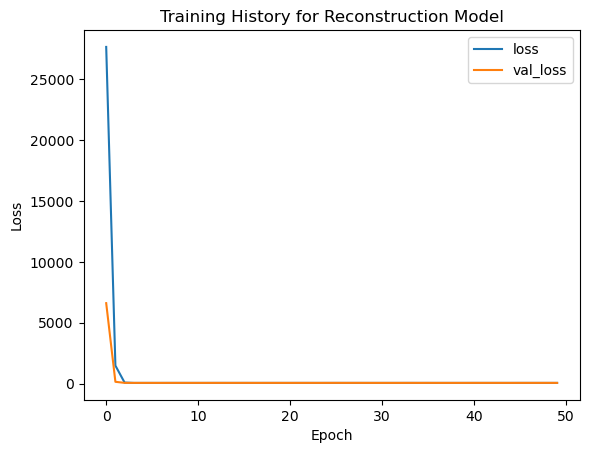

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [ 4.513858    7.728824    2.760276    0.41093007  0.3692246   0.33386096
  0.614315    0.20647657  0.19667882  2.2108016   2.1297188   2.4637284
  1.5916104  10.502926    6.43559    10.814277    7.13906   ]
Reconstruction Attack for l-Diverse Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 45546.1172 - mae: 134.1794 - val_loss: 23710.7246 - val_mae: 105.2201
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16211.6797 - mae: 89.4539 - val_loss: 2191.5437 - val_mae: 30.4923
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1117.6334 - mae: 20.2718 - val_loss: 106.2107 - val_mae: 6.0640
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 93.9403 - mae: 5.5570 - val_loss: 78.0633 - val_mae: 4.6688
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 79.0322 - mae: 4.6170 - val_loss: 77.1344 - val_mae: 4.3712
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 

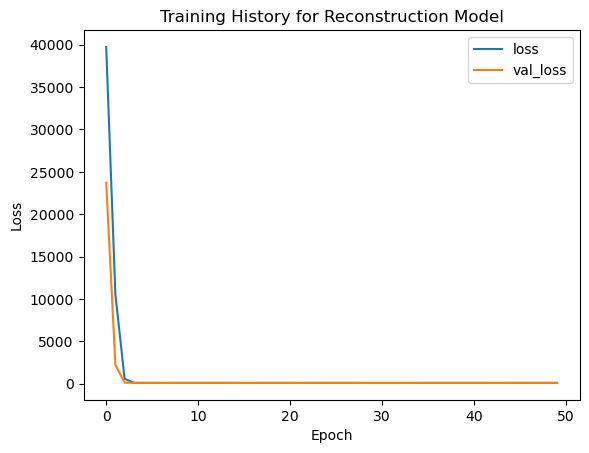

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Absolute Error for reconstructed data: [ 3.8760808   6.5840693   7.102353    1.487501    0.5904108   0.33502442
  0.7427917  13.459483    8.465404    0.4602056   1.3430339   1.049821
  0.5943087  10.095374    5.3813615   9.93912     5.2886806 ]
Reconstruction Attack for m-Invariant Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 50786.2969 - mae: 138.1173 - val_loss: 35169.9414 - val_mae: 124.0756
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26303.0645 - mae: 107.3977 - val_loss: 5604.9722 - val_mae: 54.3552
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3141.8013 - mae: 36.0070 - val_loss: 150.6775 - val_mae: 8.1676
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.3956 - mae: 6.4281 - val_loss: 80.9038 - val_mae: 4.9386
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 77.9210 - mae: 4.7255 - val_loss: 77.8830 - val_mae: 4.5803
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - los

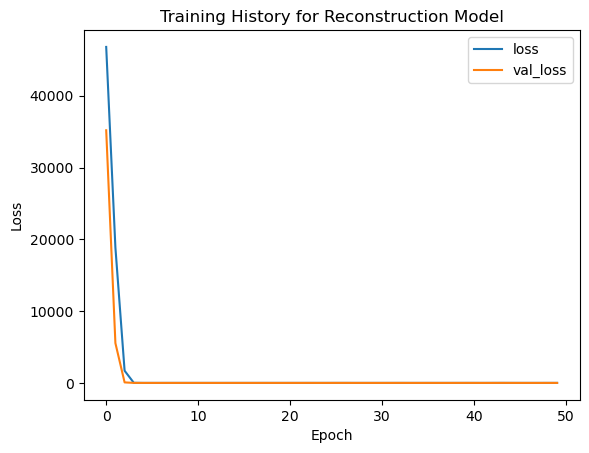

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Absolute Error for reconstructed data: [ 3.6548202   7.005226    7.539235    0.3275183   1.5174551   1.48487
  0.35054624 15.649022    9.686318    0.5640353   0.48272035  0.27875158
  0.12322685  8.972695    5.77774     9.363063    5.8385906 ]
Reconstruction Attack for t-Close Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 49319.1094 - mae: 128.8219 - val_loss: 30945.0137 - val_mae: 86.4879
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20889.0078 - mae: 72.1199 - val_loss: 2023.4185 - val_mae: 27.0063
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1210.1980 - mae: 19.4926 - val_loss: 786.8663 - val_mae: 11.5516
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 772.2186 - mae: 10.3307 - val_loss: 755.4023 - val_mae: 8.7793
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 712.9831 - mae: 8.9323 - val_loss: 750.8253 - val_mae: 9.0842
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

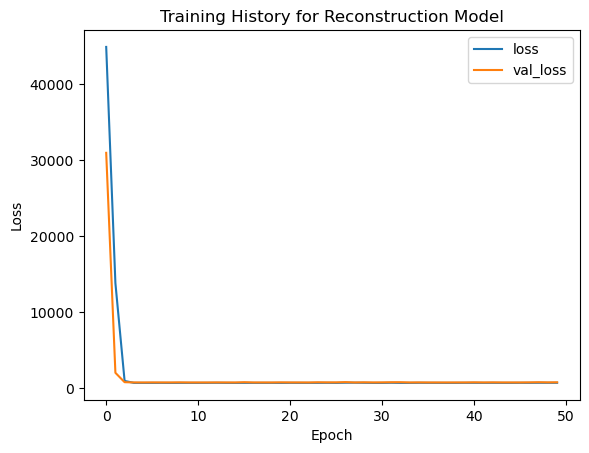

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Absolute Error for reconstructed data: [ 3.9669163   6.4015727  20.221178    0.30579022  0.31259978  0.4233804
  0.43437856 53.227383   33.941475    9.067505    6.6444726   8.857378
  5.050807    3.2011564   0.4300073   1.3162125   3.2108035 ]
         Method  MAE Systolic  MAE Diastolic
0   k-Anonymity      4.513858       7.728824
1   l-Diversity      3.876081       6.584069
2  m-Invariance      3.654820       7.005226
3   t-Closeness      3.966916       6.401573


In [221]:
import pandas as pd

# Ensure original input data is properly formatted
original_input_data = test_df.iloc[:, :-2].values.astype(np.float32)
original_input_data = np.nan_to_num(original_input_data)

# Perform reconstruction attack for each secured dataset and store the MAE results
def reconstruction_attack(predictions, original_data, description):
    print(f"Reconstruction Attack for {description}")
    reconstruction_model = train_reconstruction_model(predictions, original_data)
    reconstructed_data = evaluate_reconstruction_model(reconstruction_model, predictions, original_data)
    return np.mean(np.abs(reconstructed_data - original_data), axis=0)

# Perform reconstruction attacks
mae_kanonymity = reconstruction_attack(predictions_kanonymity, original_input_data, 'k-Anonymized Data')
mae_ldiversity = reconstruction_attack(predictions_ldiversity, original_input_data, 'l-Diverse Data')
mae_minvariance = reconstruction_attack(predictions_minvariance, original_input_data, 'm-Invariant Data')
mae_tcloseness = reconstruction_attack(predictions_tcloseness, original_input_data, 't-Close Data')

# Create a DataFrame to display the reconstruction errors
reconstruction_errors_df = pd.DataFrame({
    'Method': ['k-Anonymity', 'l-Diversity', 'm-Invariance', 't-Closeness'],
    'MAE Systolic': [mae_kanonymity[0], mae_ldiversity[0], mae_minvariance[0], mae_tcloseness[0]],
    'MAE Diastolic': [mae_kanonymity[1], mae_ldiversity[1], mae_minvariance[1], mae_tcloseness[1]]
})

# Display the reconstruction errors table
print(reconstruction_errors_df)


Reconstruction Attack for k-Anonymized Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 47919.0781 - mae: 143.8319 - val_loss: 24835.3555 - val_mae: 109.2325
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17572.8301 - mae: 93.2071 - val_loss: 925.3349 - val_mae: 21.9767
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 445.1778 - mae: 14.9285 - val_loss: 92.4832 - val_mae: 6.3331
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 65.8729 - mae: 4.9128 - val_loss: 53.3229 - val_mae: 3.7122
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 49.5732 - mae: 3.5625 - val_loss: 52.3632 - val_mae: 3.5406
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53.1711 - mae: 3.6105 - val_loss: 52.4785 - val_mae: 3.3823
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47.2102 - mae: 3.3853 - val_loss: 53.3822 - val_mae: 3.6863
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 52.3567 - mae: 3.4918 - val_loss: 52.5742 - val_mae: 3

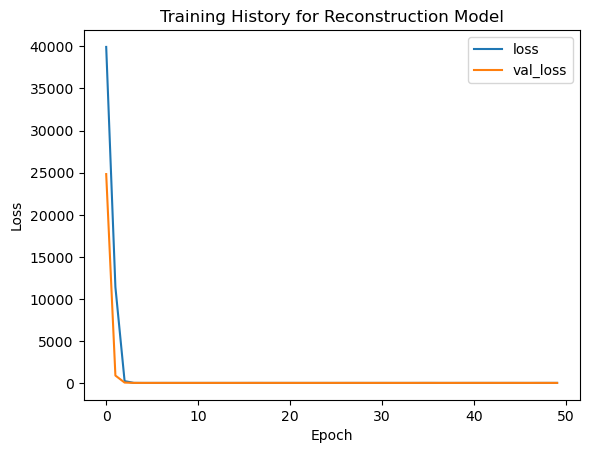

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [4.7574716  7.241455   2.4349568  0.43018937 0.44462442 0.79860824
 0.5115836  1.4529965  0.6228328  2.2212858  2.1463556  2.3380008
 2.0308821  9.948455   5.9404087  9.798681   5.822028  ]
Reconstruction Attack for l-Diverse Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 49716.3516 - mae: 134.2262 - val_loss: 31499.8789 - val_mae: 108.9832
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20705.0371 - mae: 87.9972 - val_loss: 620.7393 - val_mae: 15.9674
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 375.3913 - mae: 13.0232 - val_loss: 103.6913 - val_mae: 6.5032
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 91.9607 - mae: 5.5023 - val_loss: 76.7755 - val_mae: 4.6540
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 73.7987 - mae: 4.4322 - val_loss: 76.2286 - val_mae: 4.4135
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 76.1987 - mae: 4.42

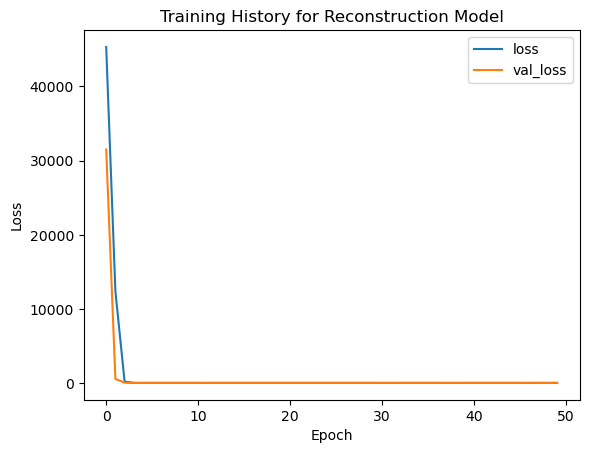

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [ 3.597703    8.448875    7.4276495   0.8234613   0.5412093   0.6279271
  0.90582865 15.76108     9.802301    0.35731855  0.89405453  0.65970546
  0.43179905  9.150038    5.514242    9.171444    5.9199634 ]
Reconstruction Attack for m-Invariant Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 50786.9453 - mae: 133.1786 - val_loss: 30479.8672 - val_mae: 97.2896
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19991.2715 - mae: 79.1050 - val_loss: 1150.0581 - val_mae: 24.9342
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 519.6339 - mae: 15.5965 - val_loss: 99.6623 - val_mae: 6.0092
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 91.8927 - mae: 5.4016 - val_loss: 78.1773 - val_mae: 4.6215
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 85.9693 - mae: 4.8843 - val_loss: 78.0201 - val_mae: 4.5522
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7

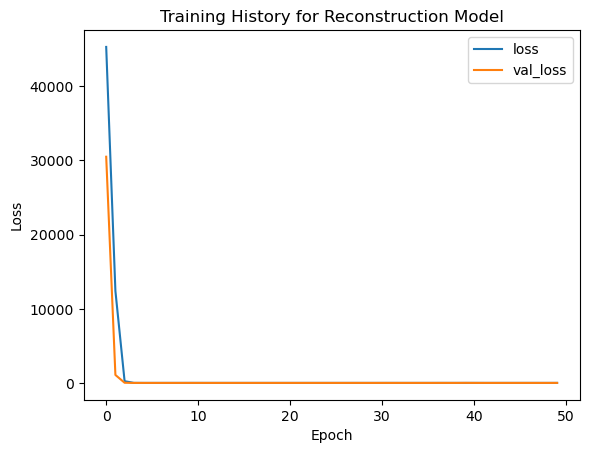

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [ 3.8539195   6.1577563   7.2233477   0.328314    0.28407586  0.45359167
  0.41214442 15.676911    9.933306    0.7711426   0.7817743   2.2851183
  1.7949628   8.531328    5.733167    8.695012    5.451477  ]
Reconstruction Attack for t-Close Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 49250.2969 - mae: 130.2262 - val_loss: 29863.2227 - val_mae: 91.1688
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20838.0840 - mae: 74.7281 - val_loss: 2424.3909 - val_mae: 31.2847
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1396.6754 - mae: 21.5879 - val_loss: 785.7867 - val_mae: 11.5736
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 684.9318 - mae: 9.9162 - val_loss: 758.9279 - val_mae: 10.1512
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 669.9312 - mae: 9.1520 - val_loss: 760.4224 - val_mae: 10.3734
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

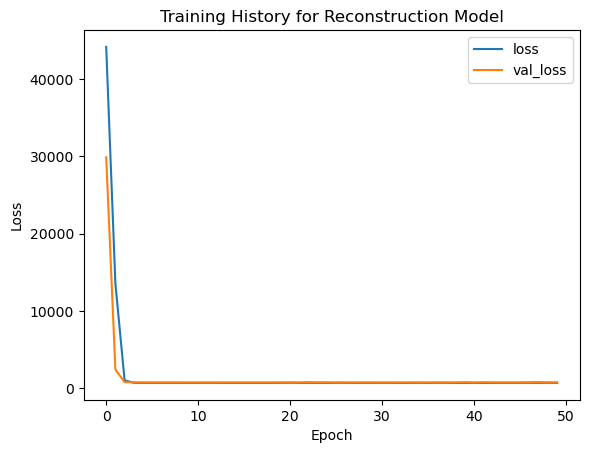

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for reconstructed data: [ 3.8000045   8.281861   20.34079     0.2991933   0.33885932  0.43387985
  0.39517114 61.044346   38.17475     9.693322    6.0227923   9.135431
  6.7750406   0.23502095  0.36356196  0.51507896  0.8468508 ]
       Feature  k-Anonymity  l-Diversity  m-Invariance  t-Closeness
0    Feature 1     4.757472     3.597703      3.853920     3.800004
1    Feature 2     7.241455     8.448875      6.157756     8.281861
2    Feature 3     2.434957     7.427649      7.223348    20.340790
3    Feature 4     0.430189     0.823461      0.328314     0.299193
4    Feature 5     0.444624     0.541209      0.284076     0.338859
5    Feature 6     0.798608     0.627927      0.453592     0.433880
6    Feature 7     0.511584     0.905829      0.412144     0.395171
7    Feature 8     1.452996    15.761080     15.676911    61.044346
8    Feature 9     0.622833     9.802301      9.933306    38.174751
9   Feature 10     2.221286    

In [222]:
import pandas as pd

# Ensure original input data is properly formatted
original_input_data = test_df.iloc[:, :-2].values.astype(np.float32)
original_input_data = np.nan_to_num(original_input_data)

# Perform reconstruction attack for each secured dataset and store the MAE results
def reconstruction_attack(predictions, original_data, description):
    print(f"Reconstruction Attack for {description}")
    reconstruction_model = train_reconstruction_model(predictions, original_data)
    reconstructed_data = evaluate_reconstruction_model(reconstruction_model, predictions, original_data)
    return np.mean(np.abs(reconstructed_data - original_data), axis=0)

# Perform reconstruction attacks
mae_kanonymity = reconstruction_attack(predictions_kanonymity, original_input_data, 'k-Anonymized Data')
mae_ldiversity = reconstruction_attack(predictions_ldiversity, original_input_data, 'l-Diverse Data')
mae_minvariance = reconstruction_attack(predictions_minvariance, original_input_data, 'm-Invariant Data')
mae_tcloseness = reconstruction_attack(predictions_tcloseness, original_input_data, 't-Close Data')

# Create a DataFrame to display the reconstruction errors
reconstruction_errors_df = pd.DataFrame({
    'Feature': ['Feature ' + str(i+1) for i in range(len(mae_kanonymity))],
    'k-Anonymity': mae_kanonymity,
    'l-Diversity': mae_ldiversity,
    'm-Invariance': mae_minvariance,
    't-Closeness': mae_tcloseness
})

# Display the reconstruction errors table
print(reconstruction_errors_df)


### Function to train an inversion model

Inversion Attack for k-Anonymized Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3000.5581 - mae: 38.2843 - val_loss: 442.4949 - val_mae: 15.6080
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 465.2588 - mae: 15.3404 - val_loss: 426.5953 - val_mae: 15.1662
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 358.7625 - mae: 13.9917 - val_loss: 433.0459 - val_mae: 15.2415
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 372.2062 - mae: 14.3619 - val_loss: 426.5353 - val_mae: 15.2258
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 356.5959 - mae: 14.1411 - val_loss: 427.3341 - val_mae: 15.1581
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 334.3232 - mae: 13.5493 - val_loss: 425.4531 - val_mae: 15.1701
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 376.9948 - mae: 14.1537 - val_loss: 426.9182 - val_mae: 15.1982
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 375.2881 - mae: 13.8598 - val_loss: 441.4158 - v

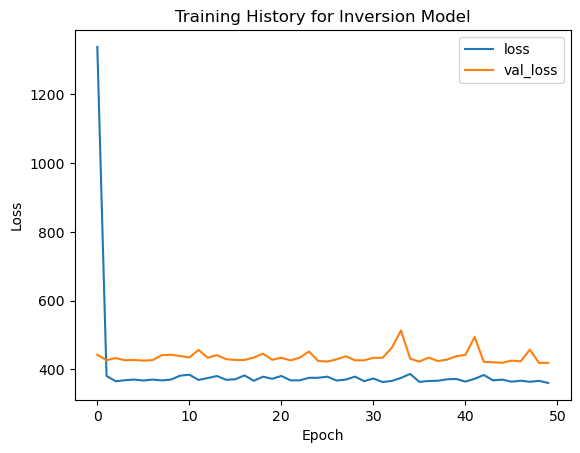

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean Absolute Error for inferred sensitive features: [17.650345 10.647764]
Inversion Attack for l-Diverse Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 9257.0684 - mae: 90.5743 - val_loss: 479.1300 - val_mae: 16.7505
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 488.1556 - mae: 16.8172 - val_loss: 409.4047 - val_mae: 14.9589
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 324.9339 - mae: 13.3350 - val_loss: 401.6635 - val_mae: 14.8112
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 296.2759 - mae: 12.7866 - val_loss: 394.1615 - val_mae: 14.6854
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 323.0208 - mae: 13.4688 - val_loss: 394.7038 - val_mae: 14.6776
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 367.6213 - mae: 14.1388 - val_loss: 396.3446 - val_mae: 14.7345
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 352.4922 - mae: 13.4580 - val_loss: 395.1314 - val_mae: 14.

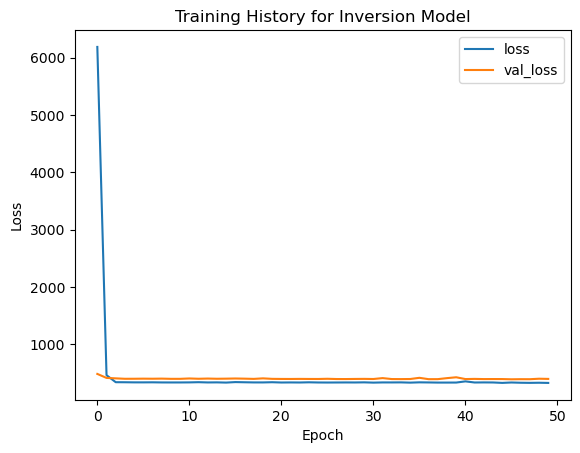

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for inferred sensitive features: [16.764267 10.233522]
Inversion Attack for m-Invariant Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8970.0576 - mae: 91.4053 - val_loss: 1856.3911 - val_mae: 39.3805
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 956.4813 - mae: 25.4399 - val_loss: 414.7864 - val_mae: 15.0503
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 334.2884 - mae: 13.4119 - val_loss: 398.3172 - val_mae: 14.7614
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 332.4732 - mae: 13.5779 - val_loss: 409.4105 - val_mae: 14.9805
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 331.0693 - mae: 13.5212 - val_loss: 399.5278 - val_mae: 14.7934
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 332.4079 - mae: 13.5276 - val_loss: 418.6491 - val_mae: 15.1379
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 355.0790 - mae: 13.8282 - val_loss: 396.6157 - val_mae: 

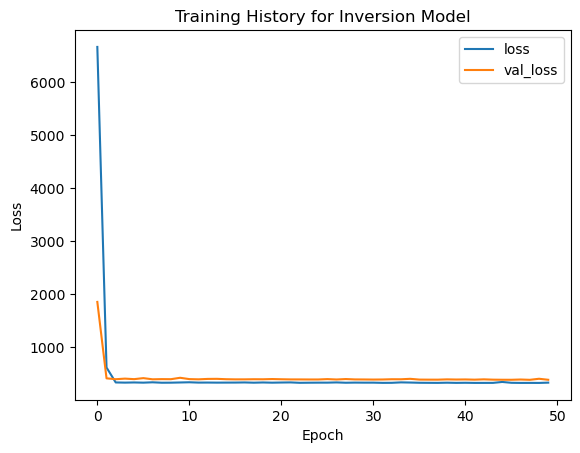

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for inferred sensitive features: [16.940496  10.2305975]
Inversion Attack for t-Close Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4508.9019 - mae: 59.4070 - val_loss: 335.2180 - val_mae: 15.4632
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 248.5022 - mae: 11.0659 - val_loss: 204.5183 - val_mae: 9.6406
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 186.4954 - mae: 8.6493 - val_loss: 208.4279 - val_mae: 9.2462
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 188.4473 - mae: 8.4865 - val_loss: 207.4014 - val_mae: 9.2802
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 196.6509 - mae: 8.4775 - val_loss: 206.1776 - val_mae: 9.1937
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 173.1209 - mae: 8.4327 - val_loss: 203.6646 - val_mae: 9.5242
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 157.4727 - mae: 8.0743 - val_loss: 205.7524 - val_mae: 9.3643
Epoch 

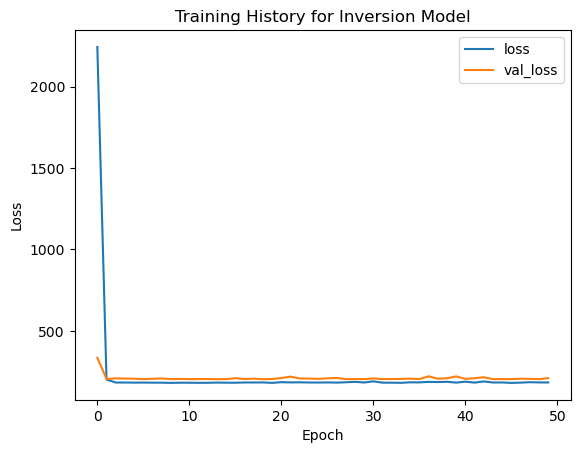

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for inferred sensitive features: [10.705909  6.330099]
Inversion Attack for Non-Secured Data
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4933.4800 - mae: 60.4365 - val_loss: 230.4950 - val_mae: 11.5740
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 230.3484 - mae: 9.2032 - val_loss: 200.6506 - val_mae: 9.2709
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 170.9942 - mae: 8.2151 - val_loss: 201.1377 - val_mae: 9.0330
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 188.3103 - mae: 8.4344 - val_loss: 201.8122 - val_mae: 8.9947
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 163.3446 - mae: 7.6751 - val_loss: 202.4855 - val_mae: 8.9733
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 181.5671 - mae: 8.2822 - val_loss: 201.6222 - val_mae: 9.0057
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 175.5546 - mae: 8.2110 - val_loss: 200.8344 - val_mae: 9.1155
Epoch

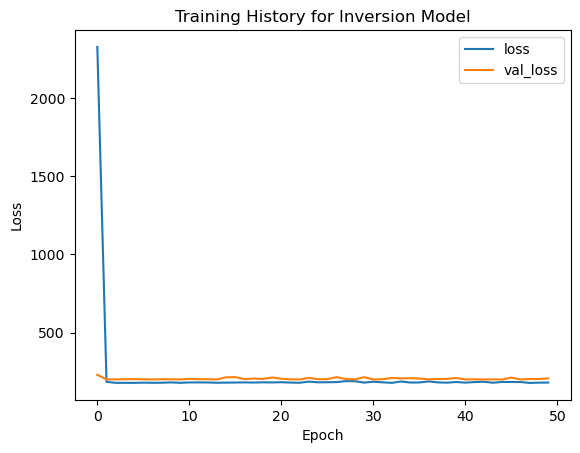

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error for inferred sensitive features: [12.4500265  6.5186157]
         Method  MAE Systolic  MAE Diastolic
0   k-Anonymity     17.650354      10.647785
1   l-Diversity     16.764240      10.233481
2  m-Invariance     16.940485      10.230613
3   t-Closeness     10.705907       6.330105
4   Non-Secured     12.450029       6.518612


In [223]:
def train_inversion_model(predictions, sensitive_features):
    X_train, X_val, y_train, y_val = train_test_split(predictions, sensitive_features, test_size=0.2, random_state=42)

    # Define the neural network model for inversion
    model_inversion = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(sensitive_features.shape[1])  # Output layer for sensitive features
    ])

    # Compile the model
    model_inversion.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train the model
    history_inversion = model_inversion.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

    # Plot training history
    plt.plot(history_inversion.history['loss'], label='loss')
    plt.plot(history_inversion.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training History for Inversion Model')
    plt.show()

    return model_inversion

# Function to evaluate the inversion model
def evaluate_inversion_model(inversion_model, predictions, sensitive_features):
    inferred_features = inversion_model.predict(predictions)
    mae = np.mean(np.abs(inferred_features - sensitive_features), axis=0)
    print(f'Mean Absolute Error for inferred sensitive features: {mae}')
    return inferred_features

# Prepare the sensitive features (systolic and diastolic blood pressure)
sensitive_features = test_df[['systolic', 'diastolic']].values.astype(np.float32)
sensitive_features = np.nan_to_num(sensitive_features)

# Perform inversion attack for each secured dataset
print("Inversion Attack for k-Anonymized Data")
inversion_model_kanonymity = train_inversion_model(predictions_kanonymity, sensitive_features)
inferred_kanonymity = evaluate_inversion_model(inversion_model_kanonymity, predictions_kanonymity, sensitive_features)

print("Inversion Attack for l-Diverse Data")
inversion_model_ldiversity = train_inversion_model(predictions_ldiversity, sensitive_features)
inferred_ldiversity = evaluate_inversion_model(inversion_model_ldiversity, predictions_ldiversity, sensitive_features)

print("Inversion Attack for m-Invariant Data")
inversion_model_minvariance = train_inversion_model(predictions_minvariance, sensitive_features)
inferred_minvariance = evaluate_inversion_model(inversion_model_minvariance, predictions_minvariance, sensitive_features)

print("Inversion Attack for t-Close Data")
inversion_model_tcloseness = train_inversion_model(predictions_tcloseness, sensitive_features)
inferred_tcloseness = evaluate_inversion_model(inversion_model_tcloseness, predictions_tcloseness, sensitive_features)

print("Inversion Attack for Non-Secured Data")
inversion_model_non_secure = train_inversion_model(predictions_non_secure, sensitive_features)
inferred_non_secure = evaluate_inversion_model(inversion_model_non_secure, predictions_non_secure, sensitive_features)

# Create a DataFrame to display the inversion errors
inversion_errors_df = pd.DataFrame({
    'Method': ['k-Anonymity', 'l-Diversity', 'm-Invariance', 't-Closeness', 'Non-Secured'],
    'MAE Systolic': [
        np.mean(np.abs(inferred_kanonymity[:, 0] - sensitive_features[:, 0])),
        np.mean(np.abs(inferred_ldiversity[:, 0] - sensitive_features[:, 0])),
        np.mean(np.abs(inferred_minvariance[:, 0] - sensitive_features[:, 0])),
        np.mean(np.abs(inferred_tcloseness[:, 0] - sensitive_features[:, 0])),
        np.mean(np.abs(inferred_non_secure[:, 0] - sensitive_features[:, 0]))
    ],
    'MAE Diastolic': [
        np.mean(np.abs(inferred_kanonymity[:, 1] - sensitive_features[:, 1])),
        np.mean(np.abs(inferred_ldiversity[:, 1] - sensitive_features[:, 1])),
        np.mean(np.abs(inferred_minvariance[:, 1] - sensitive_features[:, 1])),
        np.mean(np.abs(inferred_tcloseness[:, 1] - sensitive_features[:, 1])),
        np.mean(np.abs(inferred_non_secure[:, 1] - sensitive_features[:, 1]))
    ]
})

# Display the inversion errors table
print(inversion_errors_df)
